In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score

In [3]:
!gdown 1yWjGwmGP2E1CaRsdP1DV1ZO8XuePC7wQ

Downloading...
From (original): https://drive.google.com/uc?id=1yWjGwmGP2E1CaRsdP1DV1ZO8XuePC7wQ
From (redirected): https://drive.google.com/uc?id=1yWjGwmGP2E1CaRsdP1DV1ZO8XuePC7wQ&confirm=t&uuid=5763db8b-8dc9-48a4-9d29-c3fc07741641
To: /content/career-con-2019.zip
100% 36.5M/36.5M [00:00<00:00, 43.0MB/s]


In [4]:
!unzip career-con-2019.zip

Archive:  career-con-2019.zip
  inflating: X_test.csv              
  inflating: X_train.csv             
  inflating: sample_submission.csv   
  inflating: y_train.csv             


In [5]:
df_train = pd.read_csv("X_train.csv")
df_test =  pd.read_csv("X_test.csv")

In [6]:
df_train.shape

(487680, 13)

In [7]:
print(len(df_train["series_id"].unique()))
df_train["series_id"].unique()

3810


array([   0,    1,    2, ..., 3807, 3808, 3809])

In [8]:
df_train.head(128)

,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
0,0_0,0,0,-0.75853,-0.63435,-0.10488,-0.10597,0.107650,0.017561,0.000767,-0.74857,2.10300,-9.7532
1,0_1,0,1,-0.75853,-0.63434,-0.10490,-0.10600,0.067851,0.029939,0.003386,0.33995,1.50640,-9.4128
2,0_2,0,2,-0.75853,-0.63435,-0.10492,-0.10597,0.007275,0.028934,-0.005978,-0.26429,1.59220,-8.7267
3,0_3,0,3,-0.75852,-0.63436,-0.10495,-0.10597,-0.013053,0.019448,-0.008974,0.42684,1.09930,-10.0960
4,0_4,0,4,-0.75852,-0.63435,-0.10495,-0.10596,0.005135,0.007652,0.005245,-0.50969,1.46890,-10.4410
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0_123,0,123,-0.75943,-0.63316,-0.10470,-0.10677,0.041741,0.012857,0.016053,-0.80827,1.79890,-6.8687
124,0_124,0,124,-0.75945,-0.63313,-0.10473,-0.10683,-0.052041,-0.014752,0.021632,-0.36055,2.35620,-6.8926
125,0_125,0,125,-0.75949,-0.63309,-0.10467,-0.10690,-0.083083,-0.044480,0.031726,-0.98193,0.97328,-9.9795
126,0_126,0,126,-0.75950,-0.63307,-0.10464,-0.10693,-0.001305,-0.031012,0.017241,-0.72591,0.34931,-11.9770


In [9]:
print(df_test.shape)
print(len(df_test["series_id"].unique()))
df_test["series_id"].unique()

(488448, 13)
3816


array([   0,    1,    2, ..., 3813, 3814, 3815])

In [10]:
df_train_labels = pd.read_csv("y_train.csv")
df_train_labels.head()

,series_id,group_id,surface
0,0,13,fine_concrete
1,1,31,concrete
2,2,20,concrete
3,3,31,concrete
4,4,22,soft_tiles


In [11]:
df_train_labels["surface"].unique()

array(['fine_concrete', 'concrete', 'soft_tiles', 'tiled', 'soft_pvc',
       'hard_tiles_large_space', 'carpet', 'hard_tiles', 'wood'],
      dtype=object)

In [12]:
df_train_labels.shape

(3810, 3)

## Exploration

* Class Distribution

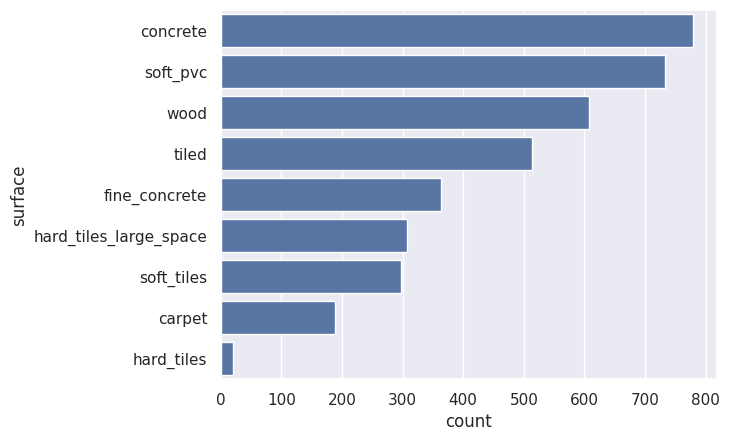

In [13]:
sns.set(style='darkgrid')
sns.countplot(y = 'surface',
              data = df_train_labels,
              order = df_train_labels['surface'].value_counts().index)
plt.show()

* series distribution

In [14]:
df_train.series_id.value_counts()

,count
series_id,
3809,128
0,128
3793,128
3792,128
3791,128
...,...
6,128
5,128
4,128


In [15]:
(df_train.series_id.value_counts() == 128).sum() == len(df_train_labels)

np.True_

## Preprocessing

### Output

* Encoding labels

In [16]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df_train_labels.surface)
print(np.unique(encoded_labels))
print(label_encoder.classes_)
df_train_labels["labels"] = encoded_labels
df_train_labels.head()

[0 1 2 3 4 5 6 7 8]
['carpet' 'concrete' 'fine_concrete' 'hard_tiles' 'hard_tiles_large_space'
 'soft_pvc' 'soft_tiles' 'tiled' 'wood']


,series_id,group_id,surface,labels
0,0,13,fine_concrete,2
1,1,31,concrete,1
2,2,20,concrete,1
3,3,31,concrete,1
4,4,22,soft_tiles,6


### Input

In [17]:
features = df_train.columns.to_list()[3:]
features

['orientation_X',
 'orientation_Y',
 'orientation_Z',
 'orientation_W',
 'angular_velocity_X',
 'angular_velocity_Y',
 'angular_velocity_Z',
 'linear_acceleration_X',
 'linear_acceleration_Y',
 'linear_acceleration_Z']

In [18]:
df_train.head(128)

,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
0,0_0,0,0,-0.75853,-0.63435,-0.10488,-0.10597,0.107650,0.017561,0.000767,-0.74857,2.10300,-9.7532
1,0_1,0,1,-0.75853,-0.63434,-0.10490,-0.10600,0.067851,0.029939,0.003386,0.33995,1.50640,-9.4128
2,0_2,0,2,-0.75853,-0.63435,-0.10492,-0.10597,0.007275,0.028934,-0.005978,-0.26429,1.59220,-8.7267
3,0_3,0,3,-0.75852,-0.63436,-0.10495,-0.10597,-0.013053,0.019448,-0.008974,0.42684,1.09930,-10.0960
4,0_4,0,4,-0.75852,-0.63435,-0.10495,-0.10596,0.005135,0.007652,0.005245,-0.50969,1.46890,-10.4410
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0_123,0,123,-0.75943,-0.63316,-0.10470,-0.10677,0.041741,0.012857,0.016053,-0.80827,1.79890,-6.8687
124,0_124,0,124,-0.75945,-0.63313,-0.10473,-0.10683,-0.052041,-0.014752,0.021632,-0.36055,2.35620,-6.8926
125,0_125,0,125,-0.75949,-0.63309,-0.10467,-0.10690,-0.083083,-0.044480,0.031726,-0.98193,0.97328,-9.9795
126,0_126,0,126,-0.75950,-0.63307,-0.10464,-0.10693,-0.001305,-0.031012,0.017241,-0.72591,0.34931,-11.9770


In [19]:
df_test.head(128)

,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
0,0_0,0,0,0.91208,-0.38193,-0.050618,0.14028,-0.060205,0.071286,-0.18787,0.29492,2.8027,-9.6816
1,0_1,0,1,0.91220,-0.38165,-0.050573,0.14028,-0.033486,0.060210,-0.18206,0.14944,2.5408,-9.8521
2,0_2,0,2,0.91228,-0.38143,-0.050586,0.14032,-0.029686,0.029476,-0.18441,-0.49741,2.5853,-9.3835
3,0_3,0,3,0.91237,-0.38121,-0.050588,0.14035,-0.024217,0.037788,-0.18783,-0.32376,2.9966,-8.7415
4,0_4,0,4,0.91247,-0.38096,-0.050546,0.14042,-0.038047,0.083405,-0.20170,-0.70103,2.6498,-8.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0_123,0,123,0.92745,-0.34256,-0.044737,0.14314,-0.042345,0.110970,-0.28062,-1.61520,3.9206,-9.7290
124,0_124,0,124,0.92757,-0.34221,-0.044644,0.14323,-0.037892,0.137240,-0.27835,0.14804,4.4519,-9.1428
125,0_125,0,125,0.92772,-0.34179,-0.044559,0.14332,-0.022882,0.140620,-0.27047,-1.20300,3.7139,-8.6641
126,0_126,0,126,0.92784,-0.34143,-0.044497,0.14338,-0.024329,0.106640,-0.28700,-0.30051,4.0866,-8.6810


In [20]:
from scipy.spatial.transform import Rotation as R

def quaternion_to_euler(df):
    r = R.from_quat(df[['orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W']].values)
    euler = r.as_euler('xyz', degrees=False) # 'xyz' is a common convention for roll, pitch, yaw
    df['roll'] = euler[:, 0] # Rotation around X-axis
    df['pitch'] = euler[:, 1] # Rotation around Y-axis
    df['yaw'] = euler[:, 2] # Rotation around Z-axis
    return df

In [21]:
# # # Apply the transformation to X_train
df_train = quaternion_to_euler(df_train.copy())
df_test = quaternion_to_euler(df_test.copy())
# # #df_train = df_train.drop(columns=['roll', 'pitch'])
# # #df_test = df_test.drop(columns=['roll', 'pitch'])

In [22]:
df_train.head(128)

,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z,roll,pitch,yaw
0,0_0,0,0,-0.75853,-0.63435,-0.10488,-0.10597,0.107650,0.017561,0.000767,-0.74857,2.10300,-9.7532,2.843273,-0.024668,1.396667
1,0_1,0,1,-0.75853,-0.63434,-0.10490,-0.10600,0.067851,0.029939,0.003386,0.33995,1.50640,-9.4128,2.843201,-0.024662,1.396651
2,0_2,0,2,-0.75853,-0.63435,-0.10492,-0.10597,0.007275,0.028934,-0.005978,-0.26429,1.59220,-8.7267,2.843222,-0.024728,1.396677
3,0_3,0,3,-0.75852,-0.63436,-0.10495,-0.10597,-0.013053,0.019448,-0.008974,0.42684,1.09930,-10.0960,2.843183,-0.024769,1.396712
4,0_4,0,4,-0.75852,-0.63435,-0.10495,-0.10596,0.005135,0.007652,0.005245,-0.50969,1.46890,-10.4410,2.843197,-0.024785,1.396698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0_123,0,123,-0.75943,-0.63316,-0.10470,-0.10677,0.041741,0.012857,0.016053,-0.80827,1.79890,-6.8687,2.842305,-0.023822,1.393537
124,0_124,0,124,-0.75945,-0.63313,-0.10473,-0.10683,-0.052041,-0.014752,0.021632,-0.36055,2.35620,-6.8926,2.842175,-0.023802,1.393463
125,0_125,0,125,-0.75949,-0.63309,-0.10467,-0.10690,-0.083083,-0.044480,0.031726,-0.98193,0.97328,-9.9795,2.842149,-0.023639,1.393325
126,0_126,0,126,-0.75950,-0.63307,-0.10464,-0.10693,-0.001305,-0.031012,0.017241,-0.72591,0.34931,-11.9770,2.842140,-0.023562,1.393269


In [23]:
# df_train['acc_energy'] = (
#     df_train['linear_acceleration_X']**2 +
#     df_train['linear_acceleration_Y']**2 +
#     df_train['linear_acceleration_Z']**2
# )

# df_train['gyro_energy'] = (
#     df_train['angular_velocity_X']**2 +
#     df_train['angular_velocity_Y']**2 +
#     df_train['angular_velocity_Z']**2
# )

# df_test['acc_energy'] = (
#     df_test['linear_acceleration_X']**2 +
#     df_test['linear_acceleration_Y']**2 +
#     df_test['linear_acceleration_Z']**2
# )

# df_test['gyro_energy'] = (
#     df_test['angular_velocity_X']**2 +
#     df_test['angular_velocity_Y']**2 +
#     df_test['angular_velocity_Z']**2
# )

In [24]:
diff_cols = [
    'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
    'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z',
    'yaw','roll', 'pitch'
]

for col in diff_cols:
    df_train[col + '_diff'] = df_train.groupby('series_id')[col].diff()
    df_test[col + '_diff'] = df_test.groupby('series_id')[col].diff()

In [25]:
# X_train = X_train.fillna(0)
# X_test = X_test.fillna(0)

* Create the rows for each serie

In [26]:
# Pivot the DataFrame
df_pivot = df_train.pivot_table(index='series_id',
                          columns='measurement_number',
                          values=[
                                  'orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W',
                                  'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
                                  'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z',
                                  'yaw','roll', 'pitch',
                                  # 'acc_energy',
                                  # 'gyro_energy',
                                   'angular_velocity_X_diff', 'angular_velocity_Y_diff', 'angular_velocity_Z_diff',
                                   'linear_acceleration_X_diff', 'linear_acceleration_Y_diff', 'linear_acceleration_Z_diff',
                                  # 'yaw_diff','roll_diff', 'pitch_diff'
                                  ],
                          aggfunc='mean')

# Flatten the multi-level columns after pivoting
df_pivot.columns = ['{}_{}'.format(var, num) for var, num in df_pivot.columns]

In [27]:
df_pivot.head()

,angular_velocity_X_0,angular_velocity_X_1,angular_velocity_X_2,angular_velocity_X_3,angular_velocity_X_4,angular_velocity_X_5,angular_velocity_X_6,angular_velocity_X_7,angular_velocity_X_8,angular_velocity_X_9,...,yaw_118,yaw_119,yaw_120,yaw_121,yaw_122,yaw_123,yaw_124,yaw_125,yaw_126,yaw_127
series_id,,,,,,,,,,,,,,,,,,,,,
0,0.107650,0.067851,0.007275,-0.013053,0.005135,0.059664,0.082140,0.056218,-0.012846,-0.090082,...,1.393888,1.393854,1.393785,1.393640,1.393561,1.393537,1.393463,1.393325,1.393269,1.393224
1,0.283420,0.108930,-0.073197,-0.064979,0.077929,0.197500,0.096969,-0.054210,-0.123730,-0.081758,...,-0.494444,-0.494220,-0.494087,-0.493993,-0.493903,-0.493812,-0.493780,-0.493661,-0.493607,-0.493727
2,-0.006752,-0.123920,-0.152710,-0.059879,0.047633,0.077444,0.022697,-0.054167,-0.080250,-0.053687,...,2.050578,2.050461,2.050409,2.050270,2.050219,2.050126,2.050017,2.049905,2.049780,2.049675
3,-0.326890,-0.093026,0.351380,0.519130,0.217070,-0.211480,-0.327970,-0.036904,0.328100,0.330960,...,-0.637515,-0.637659,-0.637803,-0.637846,-0.637865,-0.638001,-0.638170,-0.638289,-0.638319,-0.638338
4,0.025631,0.062175,0.072315,0.053529,0.043225,0.044836,0.063384,0.074720,0.080904,0.073121,...,-0.872345,-0.871780,-0.871243,-0.870708,-0.870222,-0.869745,-0.869314,-0.868896,-0.868384,-0.867984


* add label

In [28]:
df_train_labels.columns

Index(['series_id', 'group_id', 'surface', 'labels'], dtype='object')

In [29]:
df = df_pivot.merge(df_train_labels[["series_id", "labels"]], on="series_id").set_index("series_id")
df.head()

,angular_velocity_X_0,angular_velocity_X_1,angular_velocity_X_2,angular_velocity_X_3,angular_velocity_X_4,angular_velocity_X_5,angular_velocity_X_6,angular_velocity_X_7,angular_velocity_X_8,angular_velocity_X_9,...,yaw_119,yaw_120,yaw_121,yaw_122,yaw_123,yaw_124,yaw_125,yaw_126,yaw_127,labels
series_id,,,,,,,,,,,,,,,,,,,,,
0,0.107650,0.067851,0.007275,-0.013053,0.005135,0.059664,0.082140,0.056218,-0.012846,-0.090082,...,1.393854,1.393785,1.393640,1.393561,1.393537,1.393463,1.393325,1.393269,1.393224,2
1,0.283420,0.108930,-0.073197,-0.064979,0.077929,0.197500,0.096969,-0.054210,-0.123730,-0.081758,...,-0.494220,-0.494087,-0.493993,-0.493903,-0.493812,-0.493780,-0.493661,-0.493607,-0.493727,1
2,-0.006752,-0.123920,-0.152710,-0.059879,0.047633,0.077444,0.022697,-0.054167,-0.080250,-0.053687,...,2.050461,2.050409,2.050270,2.050219,2.050126,2.050017,2.049905,2.049780,2.049675,1
3,-0.326890,-0.093026,0.351380,0.519130,0.217070,-0.211480,-0.327970,-0.036904,0.328100,0.330960,...,-0.637659,-0.637803,-0.637846,-0.637865,-0.638001,-0.638170,-0.638289,-0.638319,-0.638338,1
4,0.025631,0.062175,0.072315,0.053529,0.043225,0.044836,0.063384,0.074720,0.080904,0.073121,...,-0.871780,-0.871243,-0.870708,-0.870222,-0.869745,-0.869314,-0.868896,-0.868384,-0.867984,6


In [30]:
X = df.drop("labels", axis = 1)
y = df["labels"]

### Train & Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify =y, test_size=0.2)


In [32]:
print(X_train.shape)

(3048, 2426)


In [33]:
print(X_test.shape)

(762, 2426)


# Randomized Search

In [34]:
from scipy.stats import randint

param_dist = {
              "n_estimators": [ 32, 128, 1024],
              "max_features": ['log2', 'sqrt'], # Number of features to consider at every split
              "max_depth": [24, 16, None],
              #"min_samples_split": randint(2, 50), #  Minimum number of samples required to split a node
              #"min_samples_leaf": randint(1, 50), # Minimum number of samples required at each leaf node
              "bootstrap": [True, False], # Method of selecting samples for training each tree
              "criterion": ["gini", "entropy"]}

In [35]:
%%time
from sklearn.model_selection import RandomizedSearchCV

rnd_clf = RandomizedSearchCV(estimator = RandomForestClassifier(class_weight="balanced_subsample"), param_distributions = param_dist,
                               n_iter = 20, cv = 3, scoring = "f1_macro", random_state=0, n_jobs = -1)

# Fit the random search model
rnd_clf.fit(X_train, y = y_train)

CPU times: user 2min 25s, sys: 959 ms, total: 2min 26s
Wall time: 23min 41s


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced_subsample'),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [24, 16, 10, 8, None],
                                        'max_features': ['log2', 'sqrt'],
                                        'n_estimators': [16, 32, 128, 512,
                                                         1024]},
                   random_state=0, scoring='f1_macro')

In [36]:
def report(results, n_top=3):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

In [37]:
report(rnd_clf.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: 0.772 (std: 0.036)
Parameters: {'n_estimators': 1024, 'max_features': 'log2', 'max_depth': 24, 'criterion': 'entropy', 'bootstrap': False}

Model with rank: 2
Mean validation score: 0.771 (std: 0.040)
Parameters: {'n_estimators': 128, 'max_features': 'log2', 'max_depth': 24, 'criterion': 'entropy', 'bootstrap': False}

Model with rank: 3
Mean validation score: 0.749 (std: 0.033)
Parameters: {'n_estimators': 128, 'max_features': 'sqrt', 'max_depth': 24, 'criterion': 'gini', 'bootstrap': False}

Model with rank: 4
Mean validation score: 0.748 (std: 0.018)
Parameters: {'n_estimators': 32, 'max_features': 'log2', 'max_depth': 16, 'criterion': 'entropy', 'bootstrap': True}

Model with rank: 5
Mean validation score: 0.748 (std: 0.017)
Parameters: {'n_estimators': 32, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini', 'bootstrap': False}



In [38]:
rnd_clf.best_estimator_

RandomForestClassifier(bootstrap=False, class_weight='balanced_subsample',
                       criterion='entropy', max_depth=24, max_features='log2',
                       n_estimators=1024)

In [39]:
pd.DataFrame({'Feature': X.columns,'Importance': rnd_clf.best_estimator_.feature_importances_}).sort_values(by='Importance', ascending=False)

,Feature,Importance
1750,orientation_X_92,0.001545
1614,orientation_W_84,0.001470
1643,orientation_W_113,0.001448
1640,orientation_W_110,0.001438
1696,orientation_X_38,0.001418
...,...,...
1147,linear_acceleration_Y_127,0.000069
1169,linear_acceleration_Y_diff_22,0.000068
690,angular_velocity_Z_diff_53,0.000066
1329,linear_acceleration_Z_54,0.000064


## Modeling

In [40]:
# clf = RandomForestClassifier(n_estimators=10, random_state=42)
# clf.fit(X_train, y_train)


## Evaluation

In [41]:
# Predict on the test set
y_pred = rnd_clf.predict(X_test)

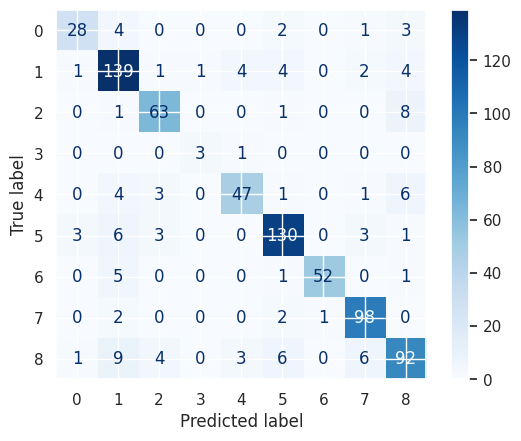

              precision    recall  f1-score   support

           0       0.85      0.74      0.79        38
           1       0.82      0.89      0.85       156
           2       0.85      0.86      0.86        73
           3       0.75      0.75      0.75         4
           4       0.85      0.76      0.80        62
           5       0.88      0.89      0.89       146
           6       0.98      0.88      0.93        59
           7       0.88      0.95      0.92       103
           8       0.80      0.76      0.78       121

    accuracy                           0.86       762
   macro avg       0.85      0.83      0.84       762
weighted avg       0.86      0.86      0.85       762



In [42]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.best_estimator_.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Print the classification report
print(classification_report(y_test, y_pred))

# Grid Search

In [52]:
param_dist = {"n_estimators": [1024], # Number of trees in random forest
              "max_features": ['log2'], # Number of features to consider at every split
              "max_depth": [48, 32, 24], # Maximum number of levels in tree
              "criterion": ['entropy'],
              "bootstrap": [False] # Method of selecting samples for training each tree
            }

In [53]:
%%time
from sklearn.model_selection import GridSearchCV

grid_clf = GridSearchCV(estimator = RandomForestClassifier(class_weight="balanced_subsample"), param_grid= param_dist,
                        scoring = "f1_macro", cv =3)

# Fit the random search model
grid_clf.fit(X = X_train, y = y_train)

CPU times: user 15min 57s, sys: 507 ms, total: 15min 58s
Wall time: 16min 13s


GridSearchCV(cv=3,
             estimator=RandomForestClassifier(class_weight='balanced_subsample'),
             param_grid={'bootstrap': [False], 'criterion': ['entropy'],
                         'max_depth': [48, 32, 24], 'max_features': ['log2'],
                         'n_estimators': [1024]},
             scoring='f1_macro')

In [54]:
report(grid_clf.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: 0.770 (std: 0.037)
Parameters: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 48, 'max_features': 'log2', 'n_estimators': 1024}

Model with rank: 2
Mean validation score: 0.768 (std: 0.036)
Parameters: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 32, 'max_features': 'log2', 'n_estimators': 1024}

Model with rank: 3
Mean validation score: 0.768 (std: 0.037)
Parameters: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 24, 'max_features': 'log2', 'n_estimators': 1024}



In [55]:
grid_clf.best_estimator_

RandomForestClassifier(bootstrap=False, class_weight='balanced_subsample',
                       criterion='entropy', max_depth=48, max_features='log2',
                       n_estimators=1024)

In [56]:
pd.DataFrame({'Feature': X.columns,'Importance': grid_clf.best_estimator_.feature_importances_}).sort_values(by='Importance', ascending=False)

,Feature,Importance
1619,orientation_W_89,0.001880
1753,orientation_X_95,0.001711
1548,orientation_W_18,0.001516
1631,orientation_W_101,0.001502
1643,orientation_W_113,0.001500
...,...,...
1104,linear_acceleration_Y_84,0.000071
681,angular_velocity_Z_diff_44,0.000070
693,angular_velocity_Z_diff_56,0.000068
1192,linear_acceleration_Y_diff_45,0.000065


In [57]:
def evaluate_model(y_test, y_pred, y_pred_proba, classes):
  # Plot the confusion matrix
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
  disp.plot(cmap=plt.cm.Blues)
  plt.show()
  # Print the classification report
  print(classification_report(y_test, y_pred))
  # roc
  ROC_AUC = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
  print('ROC AUC : {:.4f}'.format(ROC_AUC))

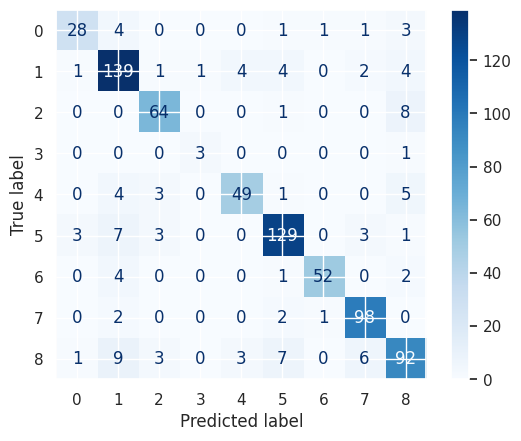

              precision    recall  f1-score   support

           0       0.85      0.74      0.79        38
           1       0.82      0.89      0.86       156
           2       0.86      0.88      0.87        73
           3       0.75      0.75      0.75         4
           4       0.88      0.79      0.83        62
           5       0.88      0.88      0.88       146
           6       0.96      0.88      0.92        59
           7       0.89      0.95      0.92       103
           8       0.79      0.76      0.78       121

    accuracy                           0.86       762
   macro avg       0.85      0.84      0.84       762
weighted avg       0.86      0.86      0.86       762

ROC AUC : 0.9869


In [58]:
best_grid = grid_clf.best_estimator_

# fit and predict
best_grid.fit( X = X_train, y = y_train)
y_pred = best_grid.predict(X_test)
y_pred_proba = best_grid.predict_proba(X_test)
evaluate_model(y_test, y_pred, y_pred_proba, best_grid.classes_)

## Generate Output


* preparing the test (submission) data set

**the same processes applied to the training dataset**

In [59]:
df_pivot_test = df_test.pivot_table(index='series_id',
                          columns='measurement_number',
                          values=[
                                  'orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W',
                                  'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
                                  'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z',
                                  'yaw','roll', 'pitch',
                                  # 'acc_energy',
                                  # 'gyro_energy',
                                   'angular_velocity_X_diff', 'angular_velocity_Y_diff', 'angular_velocity_Z_diff',
                                   'linear_acceleration_X_diff', 'linear_acceleration_Y_diff', 'linear_acceleration_Z_diff',
                                  # 'yaw_diff','roll_diff', 'pitch_diff'
                                  ],
                          aggfunc='mean')

# Flatten the multi-level columns after pivoting
df_pivot_test.columns = ['{}_{}'.format(var, num) for var, num in df_pivot_test.columns]
df_pivot_test.head()

,angular_velocity_X_0,angular_velocity_X_1,angular_velocity_X_2,angular_velocity_X_3,angular_velocity_X_4,angular_velocity_X_5,angular_velocity_X_6,angular_velocity_X_7,angular_velocity_X_8,angular_velocity_X_9,...,yaw_118,yaw_119,yaw_120,yaw_121,yaw_122,yaw_123,yaw_124,yaw_125,yaw_126,yaw_127
series_id,,,,,,,,,,,,,,,,,,,,,
0,-0.060205,-0.033486,-0.029686,-0.024217,-0.038047,-0.070700,-0.087024,-0.048412,0.007439,-0.018875,...,-0.709517,-0.708684,-0.707875,-0.706831,-0.706100,-0.705343,-0.704575,-0.703659,-0.702885,-0.702137
1,0.008170,0.032039,0.043973,0.016758,-0.022517,-0.027870,0.007311,0.040986,0.031830,0.016588,...,-2.935394,-2.933319,-2.931288,-2.929272,-2.927113,-2.925156,-2.923298,-2.921439,-2.919320,-2.917472
2,-0.031132,-0.010924,-0.026077,-0.035481,-0.006027,-0.000601,-0.004248,-0.010374,0.024392,0.048117,...,-0.781912,-0.781953,-0.781827,-0.781627,-0.781455,-0.781277,-0.781236,-0.781122,-0.781026,-0.780956
3,0.002776,0.036243,0.005197,-0.066127,-0.102760,-0.064674,-0.025599,0.001742,-0.008263,-0.026782,...,0.621124,0.619604,0.618041,0.616545,0.614962,0.613414,0.611868,0.610331,0.608747,0.607231
4,-0.016107,-0.107160,-0.105900,-0.056976,0.053479,0.077730,0.018771,-0.035045,-0.078788,-0.007367,...,-0.991355,-0.991341,-0.991332,-0.991337,-0.991258,-0.991423,-0.991659,-0.991879,-0.991952,-0.992269


* generate predictions

In [60]:
df_test

,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,...,yaw,angular_velocity_X_diff,angular_velocity_Y_diff,angular_velocity_Z_diff,linear_acceleration_X_diff,linear_acceleration_Y_diff,linear_acceleration_Z_diff,yaw_diff,roll_diff,pitch_diff
0,0_0,0,0,0.91208,-0.38193,-0.050618,0.14028,-0.060205,0.071286,-0.187870,...,-0.790891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0_1,0,1,0.91220,-0.38165,-0.050573,0.14028,-0.033486,0.060210,-0.182060,...,-0.790276,0.026719,-0.011076,0.005810,-0.14548,-0.2619,-0.1705,0.000615,0.000031,0.000009
2,0_2,0,2,0.91228,-0.38143,-0.050586,0.14032,-0.029686,0.029476,-0.184410,...,-0.789812,0.003800,-0.030734,-0.002350,-0.64685,0.0445,0.4686,0.000464,-0.000090,0.000063
3,0_3,0,3,0.91237,-0.38121,-0.050588,0.14035,-0.024217,0.037788,-0.187830,...,-0.789339,0.005469,0.008312,-0.003420,0.17365,0.4113,0.6420,0.000473,-0.000060,0.000052
4,0_4,0,4,0.91247,-0.38096,-0.050546,0.14042,-0.038047,0.083405,-0.201700,...,-0.788786,-0.013830,0.045617,-0.013870,-0.37727,-0.3468,-0.1017,0.000553,-0.000101,-0.000050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488443,3815_123,3815,123,0.89516,-0.42026,-0.056425,0.13744,0.036579,0.008990,-0.008570,...,-0.875694,-0.000176,0.005162,0.002542,1.30766,0.0147,-0.4857,0.000029,0.000078,-0.000021
488444,3815_124,3815,124,0.89517,-0.42025,-0.056391,0.13742,0.022401,0.021198,-0.010905,...,-0.875661,-0.014178,0.012208,-0.002335,-1.24644,-0.2041,-0.3567,0.000032,0.000066,-0.000040
488445,3815_125,3815,125,0.89521,-0.42019,-0.056343,0.13734,0.033571,0.019868,-0.007203,...,-0.875519,0.011170,-0.001330,0.003702,0.92213,-0.1270,-0.5688,0.000143,0.000186,0.000002
488446,3815_126,3815,126,0.89522,-0.42019,-0.056300,0.13730,0.046988,0.015570,0.001514,...,-0.875505,0.013417,-0.004298,0.008717,-0.70053,-0.3476,-0.4846,0.000014,0.000110,-0.000042


In [61]:
y_pred_sub = rnd_clf.best_estimator_.predict(df_pivot_test)

In [62]:
y_pred_sub

array([7, 4, 0, ..., 2, 6, 5])

* decoding predictions results

In [63]:
y_pred_labels = label_encoder.classes_[y_pred_sub]

In [64]:
y_pred_labels

array(['tiled', 'hard_tiles_large_space', 'carpet', ..., 'fine_concrete',
       'soft_tiles', 'soft_pvc'], dtype=object)

* preparing submission file

In [65]:
df_sub = pd.read_csv("sample_submission.csv", index_col="series_id")
df_sub.head()

,surface
series_id,
0,concrete
1,concrete
2,concrete
3,concrete
4,concrete


In [66]:
df_sub["surface"] = y_pred_labels
df_sub.head()

,surface
series_id,
0,tiled
1,hard_tiles_large_space
2,carpet
3,wood
4,concrete


In [3]:
df_sub.to_csv("submission_file.csv")

NameError: name 'df_sub' is not defined

In [2]:
from google.colab import files
files.download("submission_file.csv")

FileNotFoundError: Cannot find file: submission_file.csv